## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "physbo_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "/Users/shibukawar/workspace/nimo-fork/multi_batch_experiments_melting_temperature/./configs/physbo_batch1_trial2.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = config["batch_size"]
TOTAL_EVAL = config["total_eval"]
INITIAL_BATCH_SIZE = config["initial_batch_size"]
print(f"Initial Batch Size: {INITIAL_BATCH_SIZE}")
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

# Create output directory with batch size in name
out_dir = Path(f"./data_physbo_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

Initial Batch Size: 15
CyclesNum: 30


PosixPath('data_physbo_batch1_trial2/physbo_batch1_trial2.yaml')

In [9]:
candidates_file = out_dir / f"mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"mp_proposals_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "PHYSBO",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_melting_point
    analysis_output_functions_SO_melting_point.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")
end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  435
proposal =  [18. 24.]
###
###
number = 2
actions =  647
proposal =  [28. 48.]
###
###
number = 3
actions =  1011
proposal =  [52. 20.]
###
###
number = 4
actions =  397
proposal =  [16. 34.]
###
###
number = 5
actions =  814
proposal =  [38. 32.]
###
###
number = 6
actions =  853
proposal =  [40. 46.]
###
###
number = 7
actions =  1263
proposal =  [80.  6.]
###
###
number = 8
actions =  347
proposal =  [14. 22.]
###
###
number = 9
actions =  1289
proposal =  [84. 16.]
###
###
number = 10
actions =  396
proposal =  [16. 32.]
###
###
number = 11
actions =  863
proposal =  [42.  4.]
###
###
number = 12
actions =  1145
proposal =  [64. 18.]
###
###
number = 13
actions =  470
proposal =  [20. 10.]
###
###
number = 14
actions =  375
proposal =  [14. 78.]
###
###
number = 15
actions =  948
proposal =  [48.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!

Start selection of proposals by PHYSBO!
915224734
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 72.8174524547553
50 -th epoch marginal likelihood 72.65932815261266
100 -th epoch marginal likelihood 72.54544257319287
150 -th epoch marginal likelihood 72.47041031886233
200 -th epoch marginal likelihood 72.41988450298925
250 -th epoch marginal likelihood 72.38091784632773
300 -th epoch marginal likelihood 72.34688424265906
350 -th epoch marginal likelihood 72.31563197097529
400 -th epoch marginal likelihood 72.28660026963837
450 -th epoch marginal likelihood 72.25957966984762
500 -th epoch marginal likelihood 72.23442467856069
Done



Proposals
###
number = 1
actions =  1295
proposal =  [86. 10.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
1539124841
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 78.70058836599958
50 -th epoch marginal likelihood 78.29802274726619
100 -th epoch marginal likelihood 77.97068563338549
150 -th epoch marginal likelihood 77.68867964146241
200 -th epoch marginal likelihood 77.42921949671477
250 -th epoch marginal likelihood 77.18785722575068
300 -th epoch marginal likelihood 76.96808799601327
350 -th epoch marginal likelihood 76.77456725003408
400 -th epoch marginal likelihood 76.61082799116683
450 -th epoch marginal likelihood 76.47806130657925


...

Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 202.0290534746992
50 -th epoch marginal likelihood 199.7618683607225
100 -th epoch marginal likelihood 197.77196856660024
150 -th epoch marginal likelihood 196.02637521223684
200 -th epoch marginal likelihood 194.48891102843228
250 -th epoch marginal likelihood 193.1690645717963
300 -th epoch marginal likelihood 192.0773952878659
350 -th epoch marginal likelihood 191.19771810801774


400 -th epoch marginal likelihood 190.49009697550002
450 -th epoch marginal likelihood 189.90574137840787
500 -th epoch marginal likelihood 189.40099303409187
Done

Proposals
###
number = 1
actions =  974
proposal =  [48. 52.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
1751018860
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 206.2182976940631
50 -th epoch marginal likelihood 203.78380918019698
100 -th epoch marginal likelihood 201.6503635353959
150 -th epoch marginal likelihood 199.83975152863513
200 -th epoch marginal likelihood 198.3147520663873
250 -th epoch marginal likelihood 197.03410535054175
300 -th epoch marginal likelihood 195.97439736556936
350 -th epoch marginal likelihood 195.10981066001347


400 -th epoch marginal likelihood 194.40239585781222
450 -th epoch marginal likelihood 193.80977066574272
500 -th epoch marginal likelihood 193.29469237372885
Done

Proposals
###
number = 1
actions =  1311
proposal =  [92.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!


Elapsed time: 57.68043112754822 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


Text(0, 0.5, 'Objective')

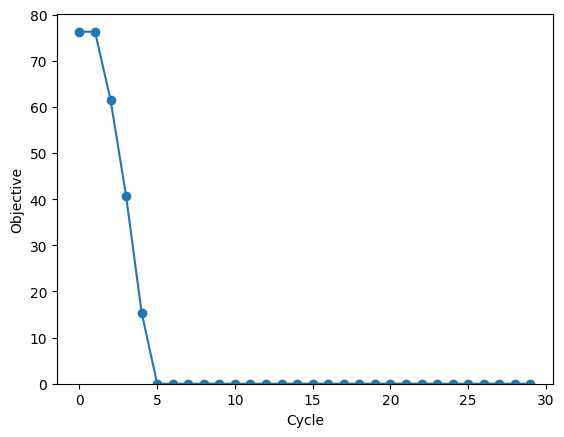

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)